In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Train over Original Dataset

In [2]:
df_class = pd.read_csv(r"df_main_classi_noise_original_headers.csv")

In [3]:
df_class

,staffed_beds,total_discharges,patient_days,gross_patient_revenue,hospitals,local_hospital,adi_natrank,adi_staternk,value_education,value_poverty,...,pop_sex_male_age_0_to_18,pop_sex_male_age_18_to_65,pop_sex_male_age_65_and_above,pct_pop_sex_female_age_0_to_18,pct_pop_sex_female_age_18_to_65,pct_pop_sex_female_age_65_and_above,pct_pop_sex_male_age_0_to_18,pct_pop_sex_male_age_18_to_65,pct_pop_sex_male_age_65_and_above,healthcare_access
0,77.0,3049.0,15984.0,250284.0,1.0,1,66.977778,4.355556,21.714286,10.400000,...,6765,16604,3683,11.463182,2.703566e+05,8.639623,12.158738,29.842378,6.619459,1
1,301.0,18080.0,78361.0,2481966.0,3.0,1,51.534483,2.655172,21.928571,10.861538,...,23873,61415,20601,10.591464,1.052924e+06,11.047282,10.936420,28.134720,9.437488,1
2,47.0,1055.0,4571.0,76099.0,1.0,1,90.900000,7.950000,22.285714,23.053846,...,2589,8494,2073,10.521058,1.189912e+05,10.804763,10.345241,33.940702,8.283385,0
3,156.0,229.0,1053.0,31288.0,1.0,1,83.411765,6.647059,21.571429,18.446154,...,2509,7896,1617,9.274157,1.064437e+05,9.202647,11.213908,35.290962,7.227138,1
4,0.0,0.0,0.0,0.0,0.0,0,72.325581,4.906977,21.571429,10.600000,...,6873,17169,4635,11.252705,2.780570e+05,9.950653,11.900268,29.727297,8.025280,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3119,58.0,1279.0,4742.0,207720.0,2.0,1,54.088235,6.147059,22.360714,8.323077,...,5805,14010,2525,12.682229,2.082663e+05,6.382636,13.390386,32.316848,5.824414,0
3120,121.0,1711.0,5932.0,273723.0,1.0,1,6.473684,1.000000,22.496429,12.092857,...,2394,8233,1708,7.698235,1.120697e+05,7.591198,10.250043,35.250043,7.312895,0
3121,32.0,803.0,1627.0,105109.0,1.0,1,57.058824,7.117647,22.500000,9.230769,...,2989,5863,1463,14.081672,9.838124e+04,6.896043,14.670658,28.776872,7.180720,0
3122,0.0,0.0,0.0,0.0,0.0,0,59.555556,7.777778,22.710714,16.021429,...,966,2256,814,11.622337,3.799210e+04,11.370225,12.176982,28.438170,10.260935,2


In [5]:
# df_class['avg_death_rate']

In [4]:
# split train and test data
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_class, test_size=0.2, random_state=42)

In [5]:
from sklearn.preprocessing import StandardScaler, scale
import statsmodels.api as sm

# train data
X_train = train.drop(columns=['healthcare_access'])
# X_names = X
y_train = train['healthcare_access']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train = sm.add_constant(X_train)

# test data
X_test = test.drop(columns=['healthcare_access'])
# X_names = X
y_test = test['healthcare_access']

X_test = scaler.transform(X_test)
X_test = sm.add_constant(X_test)


### Logistic Regression Models

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
np.random.seed(42)

strengths = [1e-1,1e0 ,1e1, 1e2, 1e3, 1e4, 1e5]

#l1 validation 

results1 = {}
print('l1')
for strength in strengths:
    print(strength)
    model = LogisticRegression(penalty = 'l1', C = strength, solver = 'liblinear', max_iter = 1000)
    model.fit(X_train,y_train) 
    avg_score = model.score(X_train,y_train)
    results1[strength] = avg_score


l1
0.1
1.0
10.0
100.0
1000.0
10000.0


In [7]:
results2 = {}
print('l2')
for strength in strengths:
    print(strength)
    model = LogisticRegression(penalty = 'l2', C = strength, solver = 'lbfgs', max_iter = 1000000)
    model.fit(X_train,y_train) 
    avg_score = model.score(X_test,y_test)
    results2[strength] = avg_score

l2
0.1
1.0
10.0
100.0
1000.0
10000.0


D:\Python3913\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of f AND g EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
best_strength_l1 = max(results1, key = results1.get) # gamma = 100
best_strength_l2 = max(results2, key = results2.get) # gamma = 1000

print(best_strength_l1, best_strength_l2) # 100000  1

10000.0 0.1


Text(0.5, 1.0, 'Logistic Regression Plot')

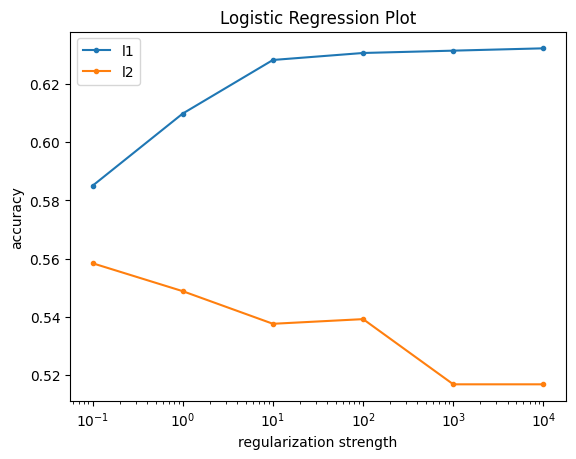

In [10]:
plt.plot(strengths, [results1[strength] for strength in strengths], '.-')
plt.plot(strengths, [results2[strength] for strength in strengths], '.-')
plt.xscale('log')
plt.legend(['l1', 'l2'])
plt.ylabel('accuracy')
plt.xlabel('regularization strength')
plt.title('Logistic Regression Plot')

# Train over 100K Dataset

In [11]:
df_100k = pd.read_csv("df_main_classi_noise_100k_headers.csv")


In [12]:
df_100k

,staffed_beds,total_discharges,patient_days,gross_patient_revenue,hospitals,local_hospital,adi_natrank,adi_staternk,value_education,value_poverty,...,pop_sex_male_age_18_to_65,pop_sex_male_age_65_and_above,pct_pop_sex_female_age_0_to_18,pct_pop_sex_female_age_18_to_65,pct_pop_sex_female_age_65_and_above,pct_pop_sex_male_age_0_to_18,pct_pop_sex_male_age_18_to_65,pct_pop_sex_male_age_65_and_above,avg_death_rate,healthcare_access
0,77.000000,3049.000000,15984.000000,2.502840e+05,1.000000,1,66.977778,4.355556,21.714286,10.400000,...,16604,3683,11.463182,2.703566e+05,8.639623,12.158738,29.842378,6.619459,0.017290,1
1,301.000000,18080.000000,78361.000000,2.481966e+06,3.000000,1,51.534483,2.655172,21.928571,10.861538,...,61415,20601,10.591464,1.052924e+06,11.047282,10.936420,28.134720,9.437488,0.010346,1
2,47.000000,1055.000000,4571.000000,7.609900e+04,1.000000,1,90.900000,7.950000,22.285714,23.053846,...,8494,2073,10.521058,1.189912e+05,10.804763,10.345241,33.940702,8.283385,0.006241,0
3,156.000000,229.000000,1053.000000,3.128800e+04,1.000000,1,83.411765,6.647059,21.571429,18.446154,...,7896,1617,9.274157,1.064437e+05,9.202647,11.213908,35.290962,7.227138,0.009041,1
4,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0,72.325581,4.906977,21.571429,10.600000,...,17169,4635,11.252705,2.780570e+05,9.950653,11.900268,29.727297,8.025280,0.005995,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99963,0.008116,0.018212,0.004773,6.406991e-03,0.019036,0,55.403612,4.692847,21.723352,8.106176,...,14108,4033,10.077360,2.213730e+05,9.715335,11.375054,30.580295,8.764798,0.034372,0
99964,0.012164,0.002017,0.004846,3.152541e-02,0.015728,0,61.502998,7.378755,22.714195,12.045667,...,3418,1001,9.837846,5.569702e+04,11.293986,11.169182,29.567837,8.683643,0.000000,0
99965,14.998087,230.007904,590.998619,1.961099e+04,1.002304,0,57.986258,4.992338,22.837736,26.187010,...,1210,271,12.273444,1.868471e+04,8.143169,16.778782,31.039347,6.930370,0.007935,0
99966,0.026108,0.009691,0.000000,1.149165e-02,0.000000,0,96.007244,10.003749,25.227402,30.315339,...,413,203,15.452900,7.396792e+03,12.071635,4.869034,27.608537,13.589307,0.103586,0


In [8]:
df_100k['avg_death_rate']

0        0.017290
1        0.010346
2        0.006241
3        0.009041
4        0.005995
           ...   
99963    0.034372
99964    0.000000
99965    0.007935
99966    0.103586
99967    0.030513
Name: avg_death_rate, Length: 99968, dtype: float64

In [35]:
# split train and test data
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_100k, test_size=0.2, random_state=42)

In [36]:

# train data
X_train = train.drop(columns=['avg_death_rate','healthcare_access'])
# X_names = X
y_train = train['healthcare_access']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train = sm.add_constant(X_train)

# test data
X_test = test.drop(columns=['avg_death_rate','healthcare_access'])
# X_names = X
y_test = test['healthcare_access']

X_test = scaler.transform(X_test)
X_test = sm.add_constant(X_test)


In [38]:
# best Logistic Regression L2 model 

l2_model = LogisticRegression(penalty = 'l2', C = 1, solver = 'lbfgs', max_iter = 1000000)
l2_model.fit(X_train,y_train)
avg_score = l2_model.score(X_test,y_test)

In [39]:
avg_score

0.7136140842252676

In [40]:
from sklearn.inspection import permutation_importance

# compute importances
model_fi = permutation_importance(l2_model, X_train, y_train)
model_fi['importances_mean']      

array([ 0.00000000e+00,  1.26516118e-02,  8.60529672e-03,  4.53147273e-03,
        2.32575587e-03,  3.13351839e-03,  4.48645810e-03,  1.27866557e-02,
        1.27541451e-04,  5.17668242e-04,  1.79808438e-03, -3.75121915e-05,
        3.38860130e-03, -2.25073149e-05,  2.94095581e-03,  2.91094606e-03,
        3.50113787e-03,  5.35674094e-03,  1.13686948e-02,  6.89223998e-03,
        2.07567459e-04,  5.28671818e-03,  4.80156051e-04,  8.25268212e-05,
        4.35141421e-04,  1.37044539e-03,  6.19951484e-03,  2.68337210e-03,
        2.99097207e-03,  2.95095906e-04,  1.88561282e-03,  3.25105659e-05,
        1.09035437e-03,  2.25823393e-03,  7.59746918e-03,  3.07599970e-04,
        2.62585340e-04,  5.76437342e-03,  2.90844524e-03,  2.15495036e-02,
        4.09032936e-02,  5.42676370e-04, -5.50178808e-05, -2.75089404e-04,
        1.30067272e-02,  8.00260085e-03,  8.62055168e-02,  1.17718258e-01,
        4.50146298e-05,  5.18918649e-03,  3.39610373e-03,  2.36326806e-03,
        2.37327131e-03,  

In [43]:
sorted_idxl2 = model_fi['importances_mean'].argsort()[::-1]

X_df = train.drop(columns=['avg_death_rate','healthcare_access'])

flag = 0
for i in sorted_idxl2:
    if flag < 20:
        flag = flag+1
        print(f"{X_df.columns[i]}:{model_fi['importances_mean'][i]}")

pct_pop_commutes_by_taxi_motorcycle_or_other:0.11771825843399104
pop_adult_education_bachelors_or_higher:0.08724085327731512
pct_pop_commutes_by_public_transport_subway:0.08620551679295774
pct_veterans_male:0.08486758196413832
pct_pop_citizenship_non_us:0.06337559706904743
households_cohabiting_couple:0.053692450046265036
households_with_computing_devices_desktop_laptop:0.05181684047315378
pop_has_3_or_more_vehicles_available:0.046677670242828914
households_with_annual_income_75000_to_99999:0.045119663890764515
pop_sex_male_age_65_and_above:0.04405931927876559
households_with_annual_income_50000_to_59999:0.04207867556956011
pct_pop_commutes_by_car_truck_van_carpool:0.04090329357041038
pct_households_cohabiting_couple:0.039767924575487036
pct_pop_works_occupation_military_related:0.037867306874734295
households_with_computing_devices_total:0.037184584990121804
pop_works_industry_educational_healthcare_social_assistance:0.0344011803836247
households_with_annual_income_less_than_30000:0.0

In [45]:
flag = 0
for i in sorted_idxl2:
    if flag < 50:
        flag = flag+1
        print(f"{X_df.columns[i]}:{model_fi['importances_mean'][i]}")

pct_pop_commutes_by_taxi_motorcycle_or_other:0.11771825843399104
pop_adult_education_bachelors_or_higher:0.08724085327731512
pct_pop_commutes_by_public_transport_subway:0.08620551679295774
pct_veterans_male:0.08486758196413832
pct_pop_citizenship_non_us:0.06337559706904743
households_cohabiting_couple:0.053692450046265036
households_with_computing_devices_desktop_laptop:0.05181684047315378
pop_has_3_or_more_vehicles_available:0.046677670242828914
households_with_annual_income_75000_to_99999:0.045119663890764515
pop_sex_male_age_65_and_above:0.04405931927876559
households_with_annual_income_50000_to_59999:0.04207867556956011
pct_pop_commutes_by_car_truck_van_carpool:0.04090329357041038
pct_households_cohabiting_couple:0.039767924575487036
pct_pop_works_occupation_military_related:0.037867306874734295
households_with_computing_devices_total:0.037184584990121804
pop_works_industry_educational_healthcare_social_assistance:0.0344011803836247
households_with_annual_income_less_than_30000:0.0

In [31]:
l2_model = LogisticRegression(penalty = 'l2', C = 0.1, solver = 'lbfgs', max_iter = 1000000)
l2_model.fit(X_train,y_train)
avg_score = l2_model.score(X_test,y_test)

In [32]:
avg_score

0.7135140542162649

In [33]:
from sklearn.inspection import permutation_importance

# compute importances
model_fi = permutation_importance(l2_model, X_train, y_train)
model_fi['importances_mean']  

array([ 0.00000000e+00,  8.06762198e-03,  9.72065921e-03,  4.95661090e-03,
        1.33043239e-03,  3.09100458e-03,  4.37142071e-03,  1.17713257e-02,
        3.07599970e-04,  1.97564208e-04,  1.84559982e-03,  3.50113787e-05,
        9.20299097e-04,  1.45047140e-04,  4.67651987e-04,  3.05099157e-04,
        4.27638983e-04,  7.47743016e-04,  1.29792182e-03,  1.14037062e-03,
        7.75251957e-05,  1.72806162e-03, -2.50081276e-06,  4.25138170e-05,
       -4.75154425e-05,  1.75056893e-04,  4.47645485e-04,  2.00065021e-05,
        8.00260085e-05,  6.75219446e-05,  8.25268212e-05, -2.15069898e-04,
        4.95160927e-04,  1.22539825e-04,  2.32575587e-04,  2.30074774e-04,
       -5.00162553e-05,  9.37804787e-04,  2.39577863e-03, -8.75284467e-05,
        1.41045840e-03, -2.50081276e-05, -1.25040638e-05,  3.00097532e-05,
        5.91442219e-03,  2.96596394e-03,  3.89301523e-02,  6.30679971e-02,
        7.25235702e-05,  3.25355741e-03,  3.47112812e-03,  2.05566809e-03,
        2.19821442e-03,  

In [34]:
sorted_idxl2 = model_fi['importances_mean'].argsort()[::-1]

X_df = train.drop(columns=['avg_death_rate','healthcare_access'])

flag = 0
for i in sorted_idxl2:
    if flag < 20:
        flag = flag+1
        print(f"{X_df.columns[i]}:{weights_l2[i]}")

pct_pop_commutes_by_taxi_motorcycle_or_other:-138.38145338957213
pct_pop_commutes_by_public_transport_subway:54.55165036648933
households_cohabiting_couple:-61.754290909866576
households_married_couple:-24.976527214976336
households_with_annual_income_75000_to_99999:-36.913547829032424
pct_households_cohabiting_couple:-35.80203652266524
households_with_annual_income_50000_to_59999:-33.314526108948925
households_with_computing_devices_desktop_laptop:65.86002868315134
pop_has_3_or_more_vehicles_available:-41.38848800039435
pop_works_occupation_management_business_science_arts:37.440442929371414
pop_total:31.77455032023668
pop_sex_male_age_65_and_above:-46.776298093583456
pop_commute_departure_0800_to_0829:-15.398806875775012
pop_adult_education_less_than_high_school:-9.105125284053532
households_with_annual_income_150000_to_199999:-20.287197627311098
pct_pop_works_occupation_military_related:4.1887473387226075
pop_commute_departure_0900_to_0959:-20.54028488854302
pop_commute_travel_time_